In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--lookback_nsample', '64',
        '--forecast_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '32',
        '--seg_nsample_trans', '16',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 626, 4])


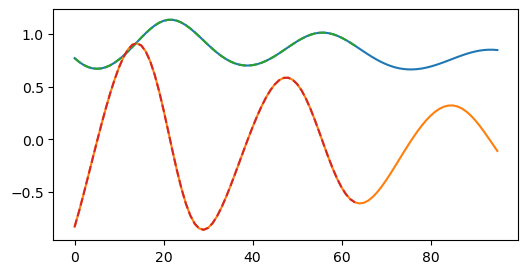

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.lookback_nsample + args.forecast_nsample]
        back = replay[:, offset:offset + args.lookback_nsample]

        true, _ = dataset.normalizer.normalize(true)
        back, _ = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        #plt.plot(true_n[jdata, :, :2])
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.094478, valid=1.008283, test=1.027293
	validation loss decreased (inf -> 1.008283), saving model ...
	epoch 2 losses: train=1.089853, valid=0.994283, test=1.003284
	validation loss decreased (1.008283 -> 0.994283), saving model ...
	epoch 3 losses: train=1.065249, valid=0.979637, test=0.993252
	validation loss decreased (0.994283 -> 0.979637), saving model ...
	epoch 4 losses: train=1.053377, valid=0.965753, test=0.981460
	validation loss decreased (0.979637 -> 0.965753), saving model ...
	epoch 5 losses: train=1.040645, valid=0.954378, test=0.969896
	validation loss decreased (0.965753 -> 0.954378), saving model ...
	epoch 6 losses: train=1.028629, valid=0.941543, test=0.957817
	validation loss decreased (0.954378 -> 0.941543), saving model ...
	epoch 7 losses: train=1.015861, valid=0.924913, test=0.943902
	validation loss decreased (0.941543 -> 0.924913), saving model ...
	epoch 8 losses: train=1.000909, valid=0.905446, test=0.92

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

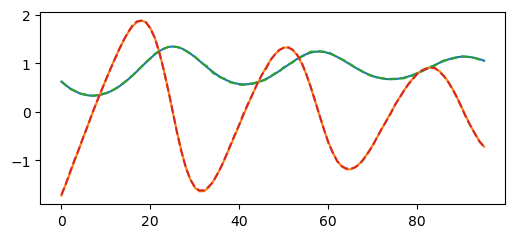

In [8]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

#print(tata.shape)

In [9]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.801488, valid=0.955728, test=0.828062
	validation loss decreased (inf -> 0.955728), saving model ...
	epoch 2 losses: train=0.775881, valid=0.944397, test=0.821105
	validation loss decreased (0.955728 -> 0.944397), saving model ...
	epoch 3 losses: train=0.764736, valid=0.935144, test=0.812360
	validation loss decreased (0.944397 -> 0.935144), saving model ...
	epoch 4 losses: train=0.755893, valid=0.926801, test=0.806203
	validation loss decreased (0.935144 -> 0.926801), saving model ...
	epoch 5 losses: train=0.748307, valid=0.918260, test=0.800810
	validation loss decreased (0.926801 -> 0.918260), saving model ...
	epoch 6 losses: train=0.740202, valid=0.909007, test=0.795028
	validation loss decreased (0.918260 -> 0.909007), saving model ...
	epoch 7 losses: train=0.731622, valid=0.898969, test=0.789086
	validation loss decreased (0.909007 -> 0.898969), saving model ...
	epoch 8 losses: train=0.722627, valid=0.888231, te

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

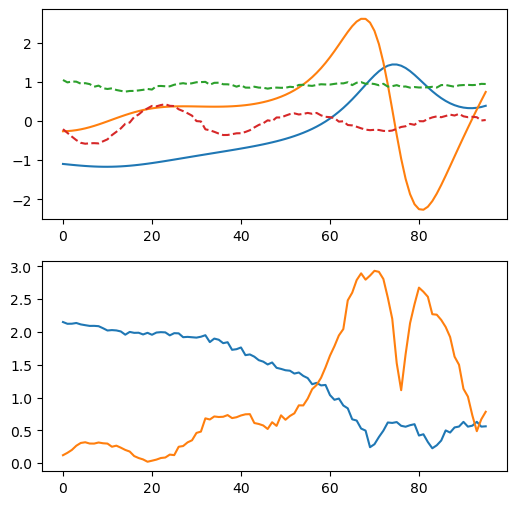

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=1.013252, valid=0.787935, test=0.901734
	validation loss decreased (inf -> 0.787935), saving model ...
	epoch 2 losses: train=0.983115, valid=0.724386, test=0.815529
	validation loss decreased (0.787935 -> 0.724386), saving model ...
	epoch 3 losses: train=0.873974, valid=0.580745, test=0.643361
	validation loss decreased (0.724386 -> 0.580745), saving model ...
	epoch 4 losses: train=0.729064, valid=0.479002, test=0.556633
	validation loss decreased (0.580745 -> 0.479002), saving model ...
	epoch 5 losses: train=0.648991, valid=0.437319, test=0.516855
	validation loss decreased (0.479002 -> 0.437319), saving model ...
	epoch 6 losses: train=0.611582, valid=0.420419, test=0.491004
	validation loss decreased (0.437319 -> 0.420419), saving model ...
	epoch 7 losses: train=0.625327, valid=0.381564, test=0.453279
	validation loss decreased (0.420419 -> 0.381564), saving model ...
	epoch 8 losses: train=0.572744, valid=0.328970, test=0.

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

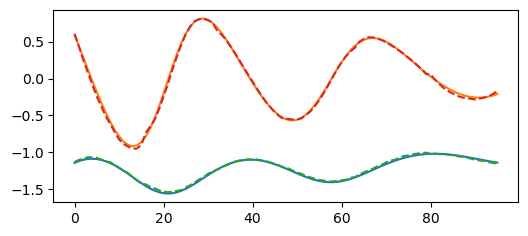

In [14]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.067919, valid=0.059021, test=0.048499
	validation loss decreased (inf -> 0.059021), saving model ...
	epoch 2 losses: train=0.045182, valid=0.053458, test=0.040910
	validation loss decreased (0.059021 -> 0.053458), saving model ...
	epoch 3 losses: train=0.040323, valid=0.049799, test=0.036686
	validation loss decreased (0.053458 -> 0.049799), saving model ...
	epoch 4 losses: train=0.035351, valid=0.046399, test=0.033592
	validation loss decreased (0.049799 -> 0.046399), saving model ...
	epoch 5 losses: train=0.034060, valid=0.043906, test=0.031961
	validation loss decreased (0.046399 -> 0.043906), saving model ...
	epoch 6 losses: train=0.031166, valid=0.042164, test=0.030877
	validation loss decreased (0.043906 -> 0.042164), saving model ...
	epoch 7 losses: train=0.031540, valid=0.040959, test=0.029820
	validation loss decreased (0.042164 -> 0.040959), saving model ...
	epoch 8 losses: train=0.030111, valid=0.040127, 

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

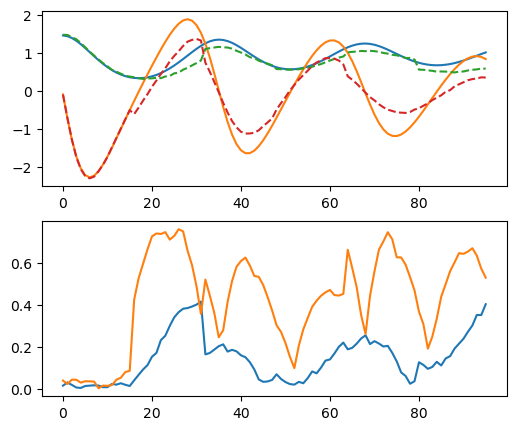

In [17]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

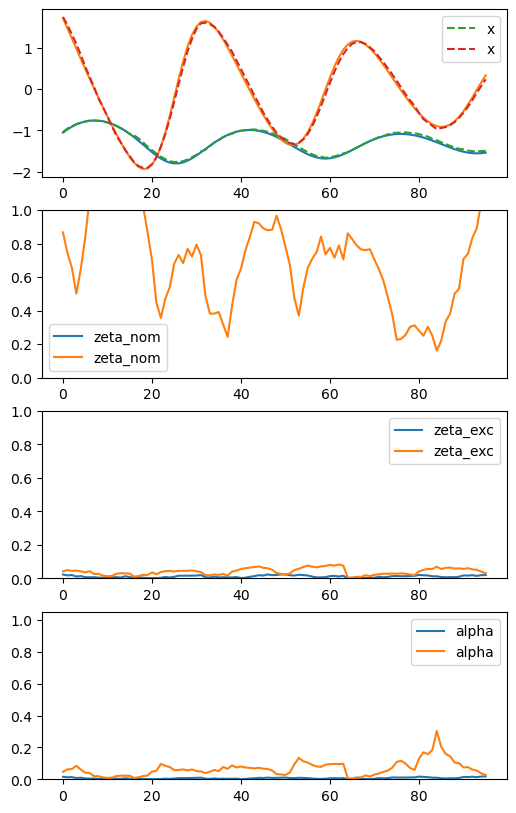

In [18]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break